<a href="https://colab.research.google.com/github/jpaguilar23/Kaggle-Titanic-Survival-Prediction/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv')

test_df = pd.read_csv('/content/test.csv')

# Guardar pasenger ids en esta variable para crear csv respuesta
passenger_ids = test_df['PassengerId']

print("Primeras filas de train_df:")
display(train_df.head())

print("\nPrimeras filas de test_df:")
display(test_df.head())

Primeras filas de train_df:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Primeras filas de test_df:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
y_train = train_df['Survived']
X_train = train_df.drop(columns=['Survived', 'PassengerId'])

x_test = test_df.drop(columns=[ 'PassengerId'])

print("Primeras filas de X_train:")
display(X_train.head())

print("\nPrimeras filas de y_train:")
display(y_train.head())

Primeras filas de X_train:


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Primeras filas de y_train:


,Survived
0,0
1,1
2,1
3,1
4,0


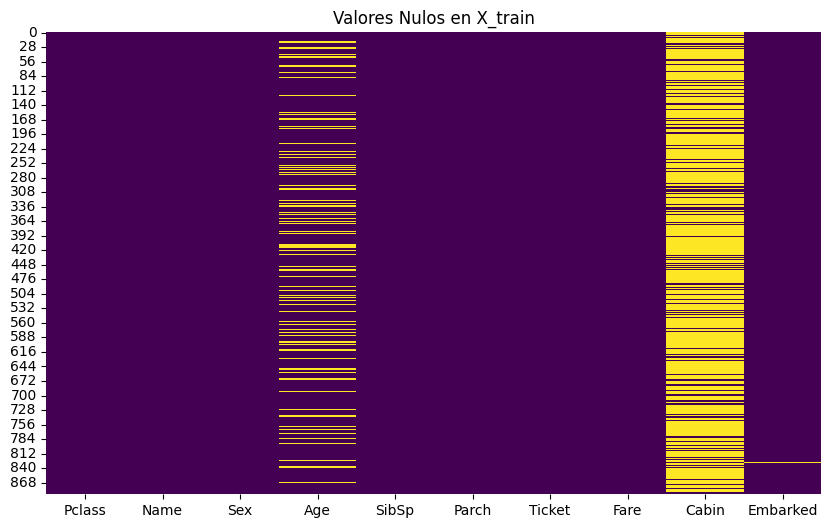



 CANTIDAD DE NULOS


,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(X_train.isnull(), cbar=False, cmap='viridis')
plt.title('Valores Nulos en X_train')
plt.show()

print("\n\n CANTIDAD DE NULOS")
null_counts1 = X_train.isnull().sum()
null_counts1



In [ ]:
columns_to_drop = ['Cabin', 'Ticket']

# Se elmina las columnas en ambos data sets
X_train.drop(columns=columns_to_drop, inplace=True, errors='ignore')
test_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [ ]:
def add_title_column(X_train):
    X_train = X_train.copy()
    X_train["title"] = X_train["Name"].str.extract(r",\s*([^\.]+)\.")
    return X_train

In [ ]:
df_with_titles = add_title_column(X_train)
display(df_with_titles.head())

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,title
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression


standarscaler_features = ['Age']
robustscaler_features = ['SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'title']

#Pipeline para el uso de Standard Scaler
standard_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Pipeline para el uso de Robust Scaler
robust_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

#Pipeline para el uso de One Hot Encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('standard', standard_pipeline, standarscaler_features),
    ('robust', robust_pipeline, robustscaler_features),
    ('cat', categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("titles", FunctionTransformer(add_title_column, validate=False)),
    ('preprocessing', preprocessor),
    ('LDA', LinearDiscriminantAnalysis(n_components=1)),
    ('LR', LogisticRegression(solver='saga', max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)

KFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prima_train = cross_val_score(model, X_train, y_train, cv=KFold, scoring='accuracy')

print("Accuracy en train :", y_prima_train.mean())

Accuracy en train : 0.8238026489234824


In [ ]:
# Generar predicciones en el conjunto de prueba (x_test)
y_pred_test = model.predict(x_test)

# Crear un DataFrame para el archivo de submission
submission_df = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': y_pred_test})

# Asegurarse de que la columna 'Survived' sea de tipo entero
submission_df['Survived'] = submission_df['Survived'].astype(int)

# Guardar el DataFrame en un archivo CSV
submission_df.to_csv('entregable_LDA.csv', index=False)

print("Predicciones generadas y guardadas en 'submission.csv'")
display(submission_df.head())

Predicciones generadas y guardadas en 'submission.csv'


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
